# Analysis of the frequency of transitions in the replay buffer

In [1]:
from itertools import batched
from marl.models.replay_memory import ReplayMemory
import marlenv
from marlenv import Transition
from marl.models.batch import TransitionBatch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from lle import LLE
import orjson

def gather_data(env: marlenv.MARLEnv, memory: ReplayMemory[Transition, TransitionBatch], n_samples: int=5000, batch_size: int=20):
    obs, state = env.reset()
    agents_positions = list[list[tuple[int, int]]]([[], [], [], []])
    for _ in range(n_samples):
        action = env.sample_action()
        step = env.step(action)
        t = Transition.from_step(obs, state, action, step)
        memory.add(t)
        batch = memory.sample(batch_size)
        for t in batch.transitions:
            pos = batched(t.state.data.tolist()[:8], 2)
            for agent_num, (i, j) in enumerate(pos):
                agents_positions[agent_num].append((int(i), int(j)))
        if step.is_terminal:
            obs, state = env.reset()
        else:
            obs = step.obs
            state = step.state
    return agents_positions

def plot_heatmaps(samples: list[list[tuple[int, int]]], width: int, height: int):
    _, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes = axes.flatten()
    for agent_num, positions in enumerate(samples):
        heatmap = np.zeros((height, width))
        for i, j in positions:
            heatmap[i, j] += 1
        sns.heatmap(heatmap, ax=axes[agent_num])
        axes[agent_num].set_title(f"Agent {agent_num} positions heatmap")
    plt.show()

def setup():
    env = LLE.level(6).obs_type("state").build()
    with open("data/lvl6-best-actions.json", "r") as f:
        actions = orjson.loads(f.read())
        episode = env.replay(actions)
    return env, episode

[200000, 200000, 200000, 200000]


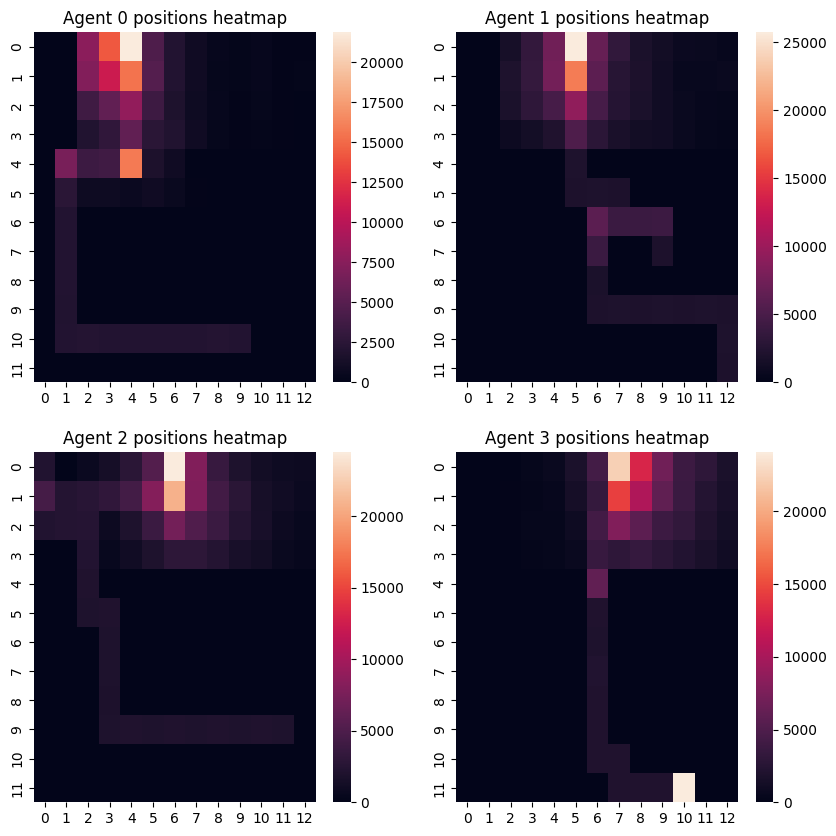

In [ ]:
from marl.models.replay_memory.biased_memory import BiasedMemory, ProbabilityBiasedTransitionMemory

env, episode = setup()
memory = BiasedMemory.from_transitions(episode.transitions(), 100, factor=1.0)
#memory = ProbabilityBiasedTransitionMemory(episode.transitions(), 1000)
agents_positions = gather_data(env, memory, n_samples=10000)
print([len(pos) for pos in agents_positions])
plot_heatmaps(agents_positions, width=env.width, height=env.height)

[200000, 200000, 200000, 200000]


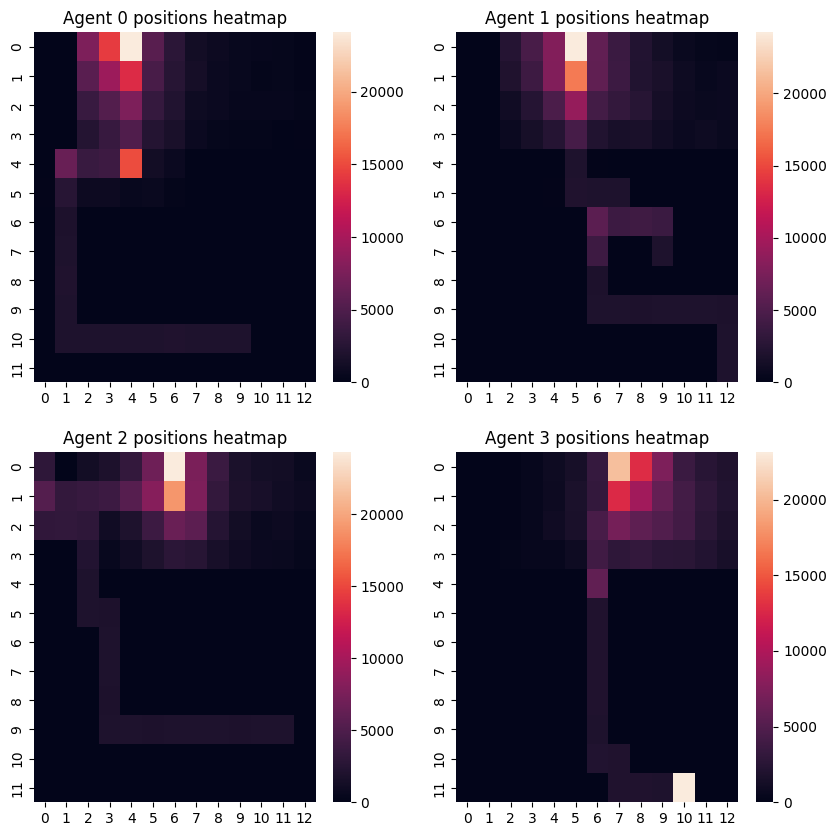

In [6]:
from marl.models.replay_memory.biased_memory import BiasedMemory

env, episode = setup()
memory = BiasedMemory.from_transitions(episode.transitions(), 10_000, factor=50.0)
# memory = ProbabilityBiasedTransitionMemory(episode.transitions(), 1000)
agents_positions = gather_data(env, memory, n_samples=10000)
print([len(pos) for pos in agents_positions])
plot_heatmaps(agents_positions, width=env.width, height=env.height)